In [1]:
import pandas as pd
import requests
from pathlib import Path
import duckdb

from run_config import PATHS

# Data Profiling on Bronze Data

Prerequisites:

data_loader -> bronze_chicago_taxi_2024.parquet
            -> bronze_weatherdata.parquet

## Taxi Data

In [2]:
TAXI_PATH = PATHS.bronze_taxi_trips

duckdb.sql(f"""
SELECT COUNT(*) AS n_rows
FROM read_parquet('{TAXI_PATH}')
""").show()

duckdb.sql(f"""
DESCRIBE SELECT *
FROM read_parquet('{TAXI_PATH}')
""").show(max_rows=100)

┌────────┐
│ n_rows │
│ int64  │
├────────┤
│ 291498 │
└────────┘

┌────────────────────────────┬──────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│        column_name         │       column_type        │  null   │   key   │ default │  extra  │
│          varchar           │         varchar          │ varchar │ varchar │ varchar │ varchar │
├────────────────────────────┼──────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ :id                        │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ :version                   │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ :created_at                │ TIMESTAMP WITH TIME ZONE │ YES     │ NULL    │ NULL    │ NULL    │
│ :updated_at                │ TIMESTAMP WITH TIME ZONE │ YES     │ NULL    │ NULL    │ NULL    │
│ trip_id                    │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ taxi_id                    │ VARCHAR             

In [3]:
duckdb.sql(f"""
SELECT count(*) 
FROM read_parquet('{TAXI_PATH}')
Where trip_seconds > 60
""").show()

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│       274447 │
└──────────────┘



## Null Values

In [4]:
con = duckdb.connect()

columns = con.sql(f"""
DESCRIBE SELECT *
FROM read_parquet('{TAXI_PATH}')
""").df()["column_name"].tolist()

parts = []

for col in columns:
    parts.append(f"""
    SELECT
        '{col}' AS column_name,
        COUNT(*) AS n_rows,
        SUM(CASE WHEN "{col}" IS NULL THEN 1 ELSE 0 END) AS n_nulls,
        ROUND(
            100.0 * SUM(CASE WHEN "{col}" IS NULL THEN 1 ELSE 0 END) / COUNT(*),
            2
        ) AS null_pct
    FROM read_parquet('{TAXI_PATH}')
    """)

query = "\nUNION ALL\n".join(parts) + "\nORDER BY null_pct DESC"

null_report = con.sql(query).df()
print(null_report.to_string(index=False))

               column_name  n_rows  n_nulls  null_pct
      dropoff_census_tract  291498 149985.0     51.45
       pickup_census_tract  291498 146778.0     50.35
    dropoff_community_area  291498  21832.0      7.49
 dropoff_centroid_location  291498  20532.0      7.04
dropoff_centroid_longitude  291498  20532.0      7.04
 dropoff_centroid_latitude  291498  20532.0      7.04
     pickup_community_area  291498   7646.0      2.62
  pickup_centroid_location  291498   7500.0      2.57
  pickup_centroid_latitude  291498   7500.0      2.57
 pickup_centroid_longitude  291498   7500.0      2.57
                     tolls  291498    305.0      0.10
                      fare  291498    305.0      0.10
                      tips  291498    305.0      0.10
                    extras  291498    305.0      0.10
                trip_total  291498    305.0      0.10
              trip_seconds  291498     35.0      0.01
              payment_type  291498      0.0      0.00
               :updated_at  

In [5]:
duckdb.sql(f"""
    SELECT 
        COUNT(*)
    FROM read_parquet('{TAXI_PATH}')
    WHERE
        pickup_centroid_location IS NULL
        AND dropoff_centroid_location IS NULL
""").show()

# can pick up and dropoff lon and lat somehow be estimated from other cols?
duckdb.sql(f"""
    SELECT 
        COUNT(*)
    FROM read_parquet('{TAXI_PATH}')
    WHERE
        pickup_centroid_location IS NULL
        AND dropoff_centroid_location IS NULL
        AND pickup_census_tract is not null
        and dropoff_census_tract is not null
""").show()

duckdb.sql(f"""
    SELECT 
        COUNT(*)
    FROM read_parquet('{TAXI_PATH}')
    WHERE
        pickup_centroid_location IS NULL
        AND dropoff_centroid_location IS NULL
        AND pickup_community_area is not null
        and dropoff_community_area  is not null
""").show()

# yes but only very few

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│         5019 │
└──────────────┘

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│           21 │
└──────────────┘

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│            0 │
└──────────────┘



In [6]:
duckdb.sql(f"""
    SELECT 
        COUNT(*)
    FROM read_parquet('{TAXI_PATH}')
    WHERE
        pickup_centroid_location IS NULL
        AND pickup_centroid_longitude IS NOT NULL
        AND pickup_centroid_latitude IS NOT NULL
""").show()

duckdb.sql(f"""
    SELECT 
        COUNT(*)
    FROM read_parquet('{TAXI_PATH}')
    WHERE
        pickup_centroid_location IS NOT NULL
        AND pickup_centroid_longitude IS NULL
        AND pickup_centroid_latitude IS NULL
""").show()

    

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│            0 │
└──────────────┘

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│            0 │
└──────────────┘



## Plausibility Checks

Columns

Trip ID
Taxi ID 
Trip Start Timestamp - check if equal or earlier then "trip end timestamp", if "trip seconds" > 15 min
Trip End Timestamp - check if equal or greater then "trip start timestamp", if "trip seconds" > 15 min
Trip Seconds - check if greater then 0 and not less then "trip end timestamp" - "trip start timestamp", look for outliers
Trip Miles - check if greater then 0, look for outliers
Pickup Census Tract -> can be dropped and reestimated using latitude and longitude
Dropoff Census Tract -> can be dropped and reestimated using latitude and longitude
Pickup Community Area
Dropoff Community Area
Fare - check if equal or greater then 0, look for outliers
Tips - check if greater then 0, look for outliers
Tolls - check if greater then 0, look for outliers
Extras - check if greater then 0, look for outliers
Trip Total - check if greater then 0, look for outliers
Payment Type
Company
Pickup Centroid Latitude - check if coordinate is reasonable for Chicago (in BROAD range of chicago)
Pickup Centroid Longitude - check if coordinate is reasonable for Chicago (in BROAD range of chicago)
Pickup Centroid Location
Dropoff Centroid Latitude - check if coordinate is reasonable for Chicago (in BROAD range of chicago)
Dropoff Centroid Longitude - check if coordinate is reasonable for Chicago (in BROAD range of chicago)
Dropoff Centroid Location


In [7]:
plausi_report = duckdb.sql(f"""
WITH base AS (
    SELECT
        *,
        TRY_CAST(trip_start_timestamp AS TIMESTAMP) AS trip_start,
        TRY_CAST(trip_end_timestamp AS TIMESTAMP) AS trip_end,

        DATE_DIFF(
            'second',
            TRY_CAST(trip_start_timestamp AS TIMESTAMP),
            TRY_CAST(trip_end_timestamp AS TIMESTAMP)
        ) AS timestamp_diff_seconds,

        trip_seconds / 60.0 AS trip_minutes,

        trip_miles / NULLIF(trip_seconds / 3600.0, 0) AS mph,

        fare / NULLIF(trip_miles, 0) AS fare_per_mile,
        tips / NULLIF(fare, 0) AS tip_rate,
        trip_total / NULLIF(trip_miles, 0) AS total_per_mile,

        ABS(
            trip_total
            - (
                COALESCE(fare, 0)
                + COALESCE(tips, 0)
                + COALESCE(tolls, 0)
                + COALESCE(extras, 0)
            )
        ) AS trip_total_component_diff

    FROM read_parquet('{TAXI_PATH}')
),

checks AS (
    SELECT
        COUNT(*) AS total_rows,

        -- IDs
        SUM(CASE WHEN trip_id IS NULL THEN 1 ELSE 0 END) AS trip_id_null,
        COUNT(*) - COUNT(DISTINCT trip_id) AS trip_id_duplicate,

        SUM(CASE WHEN taxi_id IS NULL THEN 1 ELSE 0 END) AS taxi_id_null,

        -- timestamps
        SUM(CASE WHEN trip_start IS NULL THEN 1 ELSE 0 END) AS trip_start_parse_failed,
        SUM(CASE WHEN trip_end IS NULL THEN 1 ELSE 0 END) AS trip_end_parse_failed,

        SUM(CASE
            WHEN trip_start IS NOT NULL
             AND trip_end IS NOT NULL
             AND trip_start > trip_end
            THEN 1 ELSE 0
        END) AS trip_start_after_trip_end,

        SUM(CASE
            WHEN trip_start IS NOT NULL
             AND trip_end IS NOT NULL
             AND trip_seconds > 900
             AND trip_start >= trip_end
            THEN 1 ELSE 0
        END) AS trip_start_not_before_end_for_trips_gt_15min,

        SUM(CASE
            WHEN trip_start IS NOT NULL
             AND trip_end IS NOT NULL
             AND trip_seconds > 900
             AND trip_end <= trip_start
            THEN 1 ELSE 0
        END) AS trip_end_not_after_start_for_trips_gt_15min,

        -- trip_seconds
        SUM(CASE WHEN trip_seconds IS NULL THEN 1 ELSE 0 END) AS trip_seconds_null,
        SUM(CASE WHEN trip_seconds <= 0 THEN 1 ELSE 0 END) AS trip_seconds_lte_0,

        SUM(CASE
            WHEN trip_seconds IS NOT NULL
             AND timestamp_diff_seconds IS NOT NULL
             AND trip_seconds < timestamp_diff_seconds
            THEN 1 ELSE 0
        END) AS trip_seconds_lt_timestamp_diff,

        SUM(CASE
            WHEN trip_seconds IS NOT NULL
             AND timestamp_diff_seconds IS NOT NULL
             AND ABS(trip_seconds - timestamp_diff_seconds) > 900
            THEN 1 ELSE 0
        END) AS trip_seconds_timestamp_diff_abs_gt_15min,

        SUM(CASE WHEN trip_seconds > 10800 THEN 1 ELSE 0 END) AS trip_seconds_gt_3h,
        SUM(CASE WHEN trip_seconds > 21600 THEN 1 ELSE 0 END) AS trip_seconds_gt_6h,

        -- trip_miles
        SUM(CASE WHEN trip_miles IS NULL THEN 1 ELSE 0 END) AS trip_miles_null,
        SUM(CASE WHEN trip_miles <= 0 THEN 1 ELSE 0 END) AS trip_miles_lte_0,
        SUM(CASE WHEN trip_miles > 100 THEN 1 ELSE 0 END) AS trip_miles_gt_100,
        SUM(CASE WHEN trip_miles > 250 THEN 1 ELSE 0 END) AS trip_miles_gt_250,

        -- census tracts
        SUM(CASE WHEN pickup_census_tract IS NULL THEN 1 ELSE 0 END) AS pickup_census_tract_null,
        SUM(CASE WHEN dropoff_census_tract IS NULL THEN 1 ELSE 0 END) AS dropoff_census_tract_null,

        -- community areas
        SUM(CASE WHEN pickup_community_area IS NULL THEN 1 ELSE 0 END) AS pickup_community_area_null,
        SUM(CASE
            WHEN pickup_community_area IS NOT NULL
             AND (pickup_community_area < 1 OR pickup_community_area > 77)
            THEN 1 ELSE 0
        END) AS pickup_community_area_outside_1_77,

        SUM(CASE WHEN dropoff_community_area IS NULL THEN 1 ELSE 0 END) AS dropoff_community_area_null,
        SUM(CASE
            WHEN dropoff_community_area IS NOT NULL
             AND (dropoff_community_area < 1 OR dropoff_community_area > 77)
            THEN 1 ELSE 0
        END) AS dropoff_community_area_outside_1_77,

        -- fare
        SUM(CASE WHEN fare IS NULL THEN 1 ELSE 0 END) AS fare_null,
        SUM(CASE WHEN fare <= 0 THEN 1 ELSE 0 END) AS fare_lte_0,
        SUM(CASE WHEN fare > 500 THEN 1 ELSE 0 END) AS fare_gt_500,
        SUM(CASE WHEN fare > 1000 THEN 1 ELSE 0 END) AS fare_gt_1000,

        -- tips
        SUM(CASE WHEN tips IS NULL THEN 1 ELSE 0 END) AS tips_null,
        SUM(CASE WHEN tips < 0 THEN 1 ELSE 0 END) AS tips_negative,
        SUM(CASE WHEN tips > 200 THEN 1 ELSE 0 END) AS tips_gt_200,
        SUM(CASE WHEN tip_rate > 1 THEN 1 ELSE 0 END) AS tip_rate_gt_100pct,

        -- tolls
        SUM(CASE WHEN tolls IS NULL THEN 1 ELSE 0 END) AS tolls_null,
        SUM(CASE WHEN tolls < 0 THEN 1 ELSE 0 END) AS tolls_negative,
        SUM(CASE WHEN tolls > 100 THEN 1 ELSE 0 END) AS tolls_gt_100,

        -- extras
        SUM(CASE WHEN extras IS NULL THEN 1 ELSE 0 END) AS extras_null,
        SUM(CASE WHEN extras < 0 THEN 1 ELSE 0 END) AS extras_negative,
        SUM(CASE WHEN extras > 100 THEN 1 ELSE 0 END) AS extras_gt_100,

        -- trip_total
        SUM(CASE WHEN trip_total IS NULL THEN 1 ELSE 0 END) AS trip_total_null,
        SUM(CASE WHEN trip_total <= 0 THEN 1 ELSE 0 END) AS trip_total_lte_0,
        SUM(CASE WHEN trip_total > 1000 THEN 1 ELSE 0 END) AS trip_total_gt_1000,
        SUM(CASE WHEN trip_total_component_diff > 0.01 THEN 1 ELSE 0 END) AS trip_total_component_mismatch_gt_1_cent,

        -- payment type
        SUM(CASE WHEN payment_type IS NULL THEN 1 ELSE 0 END) AS payment_type_null,
        SUM(CASE WHEN TRIM(payment_type) = '' THEN 1 ELSE 0 END) AS payment_type_empty,

        -- company
        SUM(CASE WHEN company IS NULL THEN 1 ELSE 0 END) AS company_null,
        SUM(CASE WHEN TRIM(company) = '' THEN 1 ELSE 0 END) AS company_empty,

        -- pickup latitude / longitude
        SUM(CASE WHEN pickup_centroid_latitude IS NULL THEN 1 ELSE 0 END) AS pickup_lat_null,
        SUM(CASE
            WHEN pickup_centroid_latitude IS NOT NULL
             AND (pickup_centroid_latitude < 41 OR pickup_centroid_latitude > 43)
            THEN 1 ELSE 0
        END) AS pickup_lat_outside_broad_chicago_range,

        SUM(CASE WHEN pickup_centroid_longitude IS NULL THEN 1 ELSE 0 END) AS pickup_lon_null,
        SUM(CASE
            WHEN pickup_centroid_longitude IS NOT NULL
             AND (pickup_centroid_longitude < -89 OR pickup_centroid_longitude > -87)
            THEN 1 ELSE 0
        END) AS pickup_lon_outside_broad_chicago_range,

        SUM(CASE WHEN pickup_centroid_location IS NULL THEN 1 ELSE 0 END) AS pickup_location_null,

        -- dropoff latitude / longitude
        SUM(CASE WHEN dropoff_centroid_latitude IS NULL THEN 1 ELSE 0 END) AS dropoff_lat_null,
        SUM(CASE
            WHEN dropoff_centroid_latitude IS NOT NULL
             AND (dropoff_centroid_latitude < 41 OR dropoff_centroid_latitude > 43)
            THEN 1 ELSE 0
        END) AS dropoff_lat_outside_broad_chicago_range,

        SUM(CASE WHEN dropoff_centroid_longitude IS NULL THEN 1 ELSE 0 END) AS dropoff_lon_null,
        SUM(CASE
            WHEN dropoff_centroid_longitude IS NOT NULL
             AND (dropoff_centroid_longitude < -89 OR dropoff_centroid_longitude > -87)
            THEN 1 ELSE 0
        END) AS dropoff_lon_outside_broad_chicago_range,

        SUM(CASE WHEN dropoff_centroid_location IS NULL THEN 1 ELSE 0 END) AS dropoff_location_null,

        -- derived plausibility
        SUM(CASE WHEN mph > 100 THEN 1 ELSE 0 END) AS mph_gt_100,
        SUM(CASE WHEN fare_per_mile > 50 THEN 1 ELSE 0 END) AS fare_per_mile_gt_50,
        SUM(CASE WHEN total_per_mile > 100 THEN 1 ELSE 0 END) AS total_per_mile_gt_100

    FROM base
),

long AS (
    -- Trip ID
    SELECT 'trip_id' AS column_name, 'is_null' AS check_name, trip_id_null AS n_rows, total_rows, 'high' AS severity FROM checks
    UNION ALL SELECT 'trip_id', 'duplicate', trip_id_duplicate, total_rows, 'high' FROM checks

    -- Taxi ID
    UNION ALL SELECT 'taxi_id', 'is_null', taxi_id_null, total_rows, 'medium' FROM checks

    -- Trip Start Timestamp
    UNION ALL SELECT 'trip_start_timestamp', 'parse_failed', trip_start_parse_failed, total_rows, 'high' FROM checks
    UNION ALL SELECT 'trip_start_timestamp', 'after_trip_end_timestamp', trip_start_after_trip_end, total_rows, 'high' FROM checks
    UNION ALL SELECT 'trip_start_timestamp', 'not_before_end_when_trip_seconds_gt_15min', trip_start_not_before_end_for_trips_gt_15min, total_rows, 'high' FROM checks

    -- Trip End Timestamp
    UNION ALL SELECT 'trip_end_timestamp', 'parse_failed', trip_end_parse_failed, total_rows, 'high' FROM checks
    UNION ALL SELECT 'trip_end_timestamp', 'not_after_start_when_trip_seconds_gt_15min', trip_end_not_after_start_for_trips_gt_15min, total_rows, 'high' FROM checks

    -- Trip Seconds
    UNION ALL SELECT 'trip_seconds', 'is_null', trip_seconds_null, total_rows, 'high' FROM checks
    UNION ALL SELECT 'trip_seconds', '<= 0', trip_seconds_lte_0, total_rows, 'high' FROM checks
    UNION ALL SELECT 'trip_seconds', '< timestamp_diff_seconds', trip_seconds_lt_timestamp_diff, total_rows, 'medium' FROM checks
    UNION ALL SELECT 'trip_seconds', 'abs(trip_seconds - timestamp_diff_seconds) > 15min', trip_seconds_timestamp_diff_abs_gt_15min, total_rows, 'medium' FROM checks
    UNION ALL SELECT 'trip_seconds', '> 3h', trip_seconds_gt_3h, total_rows, 'medium' FROM checks
    UNION ALL SELECT 'trip_seconds', '> 6h', trip_seconds_gt_6h, total_rows, 'high' FROM checks

    -- Trip Miles
    UNION ALL SELECT 'trip_miles', 'is_null', trip_miles_null, total_rows, 'high' FROM checks
    UNION ALL SELECT 'trip_miles', '<= 0', trip_miles_lte_0, total_rows, 'high' FROM checks
    UNION ALL SELECT 'trip_miles', '> 100 miles', trip_miles_gt_100, total_rows, 'medium' FROM checks
    UNION ALL SELECT 'trip_miles', '> 250 miles', trip_miles_gt_250, total_rows, 'high' FROM checks

    -- Census Tract
    UNION ALL SELECT 'pickup_census_tract', 'is_null', pickup_census_tract_null, total_rows, 'info' FROM checks
    UNION ALL SELECT 'dropoff_census_tract', 'is_null', dropoff_census_tract_null, total_rows, 'info' FROM checks

    -- Community Area
    UNION ALL SELECT 'pickup_community_area', 'is_null', pickup_community_area_null, total_rows, 'medium' FROM checks
    UNION ALL SELECT 'pickup_community_area', 'outside 1..77', pickup_community_area_outside_1_77, total_rows, 'high' FROM checks
    UNION ALL SELECT 'dropoff_community_area', 'is_null', dropoff_community_area_null, total_rows, 'medium' FROM checks
    UNION ALL SELECT 'dropoff_community_area', 'outside 1..77', dropoff_community_area_outside_1_77, total_rows, 'high' FROM checks

    -- Fare
    UNION ALL SELECT 'fare', 'is_null', fare_null, total_rows, 'high' FROM checks
    UNION ALL SELECT 'fare', '<= 0', fare_lte_0, total_rows, 'high' FROM checks
    UNION ALL SELECT 'fare', '> 500', fare_gt_500, total_rows, 'medium' FROM checks
    UNION ALL SELECT 'fare', '> 1000', fare_gt_1000, total_rows, 'high' FROM checks

    -- Tips
    UNION ALL SELECT 'tips', 'is_null', tips_null, total_rows, 'medium' FROM checks
    UNION ALL SELECT 'tips', '< 0', tips_negative, total_rows, 'high' FROM checks
    UNION ALL SELECT 'tips', '> 200', tips_gt_200, total_rows, 'medium' FROM checks
    UNION ALL SELECT 'tips', 'tip_rate > 100%', tip_rate_gt_100pct, total_rows, 'medium' FROM checks

    -- Tolls
    UNION ALL SELECT 'tolls', 'is_null', tolls_null, total_rows, 'medium' FROM checks
    UNION ALL SELECT 'tolls', '< 0', tolls_negative, total_rows, 'high' FROM checks
    UNION ALL SELECT 'tolls', '> 100', tolls_gt_100, total_rows, 'medium' FROM checks

    -- Extras
    UNION ALL SELECT 'extras', 'is_null', extras_null, total_rows, 'medium' FROM checks
    UNION ALL SELECT 'extras', '< 0', extras_negative, total_rows, 'high' FROM checks
    UNION ALL SELECT 'extras', '> 100', extras_gt_100, total_rows, 'medium' FROM checks

    -- Trip Total
    UNION ALL SELECT 'trip_total', 'is_null', trip_total_null, total_rows, 'high' FROM checks
    UNION ALL SELECT 'trip_total', '<= 0', trip_total_lte_0, total_rows, 'high' FROM checks
    UNION ALL SELECT 'trip_total', '> 1000', trip_total_gt_1000, total_rows, 'medium' FROM checks
    UNION ALL SELECT 'trip_total', 'fare + tips + tolls + extras mismatch > 0.01', trip_total_component_mismatch_gt_1_cent, total_rows, 'medium' FROM checks

    -- Payment Type
    UNION ALL SELECT 'payment_type', 'is_null', payment_type_null, total_rows, 'medium' FROM checks
    UNION ALL SELECT 'payment_type', 'empty string', payment_type_empty, total_rows, 'medium' FROM checks

    -- Company
    UNION ALL SELECT 'company', 'is_null', company_null, total_rows, 'medium' FROM checks
    UNION ALL SELECT 'company', 'empty string', company_empty, total_rows, 'medium' FROM checks

    -- Pickup Coordinates
    UNION ALL SELECT 'pickup_centroid_latitude', 'is_null', pickup_lat_null, total_rows, 'medium' FROM checks
    UNION ALL SELECT 'pickup_centroid_latitude', 'outside broad Chicago range 41..43', pickup_lat_outside_broad_chicago_range, total_rows, 'high' FROM checks
    UNION ALL SELECT 'pickup_centroid_longitude', 'is_null', pickup_lon_null, total_rows, 'medium' FROM checks
    UNION ALL SELECT 'pickup_centroid_longitude', 'outside broad Chicago range -89..-87', pickup_lon_outside_broad_chicago_range, total_rows, 'high' FROM checks
    UNION ALL SELECT 'pickup_centroid_location', 'is_null', pickup_location_null, total_rows, 'medium' FROM checks

    -- Dropoff Coordinates
    UNION ALL SELECT 'dropoff_centroid_latitude', 'is_null', dropoff_lat_null, total_rows, 'medium' FROM checks
    UNION ALL SELECT 'dropoff_centroid_latitude', 'outside broad Chicago range 41..43', dropoff_lat_outside_broad_chicago_range, total_rows, 'high' FROM checks
    UNION ALL SELECT 'dropoff_centroid_longitude', 'is_null', dropoff_lon_null, total_rows, 'medium' FROM checks
    UNION ALL SELECT 'dropoff_centroid_longitude', 'outside broad Chicago range -89..-87', dropoff_lon_outside_broad_chicago_range, total_rows, 'high' FROM checks
    UNION ALL SELECT 'dropoff_centroid_location', 'is_null', dropoff_location_null, total_rows, 'medium' FROM checks

    -- Derived Outlier Checks
    UNION ALL SELECT 'mph', '> 100 mph', mph_gt_100, total_rows, 'medium' FROM checks
    UNION ALL SELECT 'fare_per_mile', '> 50', fare_per_mile_gt_50, total_rows, 'medium' FROM checks
    UNION ALL SELECT 'total_per_mile', '> 100', total_per_mile_gt_100, total_rows, 'medium' FROM checks
)

SELECT
    column_name,
    check_name,
    n_rows,
    ROUND(100.0 * n_rows / total_rows, 4) AS pct,
    severity
FROM long
ORDER BY
    CASE severity
        WHEN 'high' THEN 1
        WHEN 'medium' THEN 2
        WHEN 'info' THEN 3
        ELSE 4
    END,
    n_rows DESC,
    column_name,
    check_name
""").df()

problem_checks = (
    plausi_report
    .query("n_rows > 0")
    .sort_values(["severity", "n_rows"], ascending=[True, False])
)

print(problem_checks.to_string(index=False))

               column_name                                   check_name   n_rows     pct severity
                trip_miles                                         <= 0  21203.0  7.2738     high
              trip_seconds                                         <= 0   3197.0  1.0967     high
                      fare                                         <= 0    753.0  0.2583     high
                trip_total                                         <= 0    730.0  0.2504     high
                      fare                                      is_null    305.0  0.1046     high
                trip_total                                      is_null    305.0  0.1046     high
              trip_seconds                                         > 6h    125.0  0.0429     high
                      fare                                       > 1000     63.0  0.0216     high
              trip_seconds                                      is_null     35.0  0.0120     high
        trip_end_tim

## Profiling zur Begründung der Filtergrenzen

Die folgenden Analysen verwenden die Population **nach den bestehenden Silver-Plausibilitätsfiltern**, aber vor der Aufteilung nach Spatial Units. Quantile dienen zur Einordnung und nicht als automatische Cut-offs. Die vorgeschlagenen Grenzen sind bewusst rund und liegen deutlich oberhalb des normalen Wertebereichs.

In [8]:
# Reproduce the current common Silver population without writing any data.
BASELINE_FILTERED_TAXI_SQL = f"""
SELECT * EXCLUDE (_key_count)
FROM (
    SELECT
        *,
        COUNT(*) OVER (
            PARTITION BY taxi_id, trip_start_timestamp, pickup_centroid_location
        ) AS _key_count
    FROM read_parquet('{TAXI_PATH}')
    WHERE pickup_centroid_latitude IS NOT NULL
      AND pickup_centroid_longitude IS NOT NULL
      AND pickup_community_area IS NOT NULL
      AND taxi_id IS NOT NULL
      AND trip_start_timestamp IS NOT NULL
      AND pickup_centroid_location IS NOT NULL
)
WHERE _key_count = 1
  AND trip_miles > 0 AND trip_miles <= 250
  AND trip_seconds > 59 AND trip_seconds <= 10800
  AND fare > 0
  AND tips >= 0
  AND tolls >= 0
  AND extras >= 0
  AND trip_total > 0
"""

profile_columns = [
    "trip_miles", "trip_seconds", "fare", "tips", "tolls", "extras", "trip_total"
]

quantiles = {
    "min": "MIN({column})",
    "p01": "QUANTILE_CONT({column}, 0.01)",
    "p50": "QUANTILE_CONT({column}, 0.50)",
    "p95": "QUANTILE_CONT({column}, 0.95)",
    "p99": "QUANTILE_CONT({column}, 0.99)",
    "p995": "QUANTILE_CONT({column}, 0.995)",
    "p999": "QUANTILE_CONT({column}, 0.999)",
    "max": "MAX({column})",
}
quantile_expressions = [
    f"{expression.format(column=column)} AS {column}__{statistic}"
    for column in profile_columns
    for statistic, expression in quantiles.items()
]
all_quantiles = con.sql(f"""
    SELECT {', '.join(quantile_expressions)}
    FROM ({BASELINE_FILTERED_TAXI_SQL})
""").df().iloc[0]

quantile_rows = [
    {
        "column": column,
        **{
            statistic: all_quantiles[f"{column}__{statistic}"]
            for statistic in quantiles
        },
    }
    for column in profile_columns
]

filter_quantiles = pd.DataFrame(quantile_rows)
filter_quantiles

,column,min,p01,p50,p95,p99,p995,p999,max
0,trip_miles,0.01,0.31,2.89,18.19,25.89,29.2000,39.47506,142.89
1,trip_seconds,60.00,153.00,854.00,3178.00,4542.00,5062.5800,6908.79000,10755.00
2,fare,0.01,4.50,13.27,49.00,69.00,77.0000,101.00000,330.00
3,tips,0.00,0.00,0.00,10.80,15.50,18.4979,25.76790,100.00
4,tolls,0.00,0.00,0.00,0.00,0.00,2.0000,6.00000,909.88
5,extras,0.00,0.00,0.00,6.00,29.00,36.0000,53.50000,250.00
6,trip_total,0.01,4.75,15.00,65.33,93.75,109.5000,159.87160,979.38


In [9]:
# Conservative candidates only; no Silver data is changed here.
candidate_upper_limits = {
    "fare": 500,
    "tips": 200,
    "tolls": 100,
    "extras": 100,
    "trip_total": 1000,
}

combined_condition = " OR ".join(
    f"{column} > {upper_limit}"
    for column, upper_limit in candidate_upper_limits.items()
)
impact_expressions = [
    f"SUM(CASE WHEN {column} > {upper_limit} THEN 1 ELSE 0 END) AS {column}_affected"
    for column, upper_limit in candidate_upper_limits.items()
]
impact_stats = con.sql(f"""
    SELECT
        COUNT(*) AS baseline_rows,
        {', '.join(impact_expressions)},
        SUM(CASE WHEN {combined_condition} THEN 1 ELSE 0 END) AS combined_affected
    FROM ({BASELINE_FILTERED_TAXI_SQL})
""").df().iloc[0]
baseline_rows = impact_stats["baseline_rows"]

impact_rows = []
for column, upper_limit in candidate_upper_limits.items():
    affected_rows = impact_stats[f"{column}_affected"]
    stats = filter_quantiles.loc[filter_quantiles["column"] == column].iloc[0]
    impact_rows.append({
        "criterion": f"{column} > {upper_limit}",
        "upper_limit": upper_limit,
        "p999": stats["p999"],
        "max": stats["max"],
        "affected_rows": affected_rows,
        "affected_pct": 100 * affected_rows / baseline_rows,
    })

impact_rows.append({
    "criterion": "at least one candidate upper limit",
    "upper_limit": None,
    "p999": None,
    "max": None,
    "affected_rows": impact_stats["combined_affected"],
    "affected_pct": 100 * impact_stats["combined_affected"] / baseline_rows,
})

filter_impact = pd.DataFrame(impact_rows)
filter_impact

,criterion,upper_limit,p999,max,affected_rows,affected_pct
0,fare > 500,500.0,101.0000,330.00,0.0,0.000000
1,tips > 200,200.0,25.7679,100.00,0.0,0.000000
2,tolls > 100,100.0,6.0000,909.88,1.0,0.000387
3,extras > 100,100.0,53.5000,250.00,16.0,0.006186
4,trip_total > 1000,1000.0,159.8716,979.38,0.0,0.000000
5,at least one candidate upper limit,NaN,NaN,NaN,17.0,0.006573


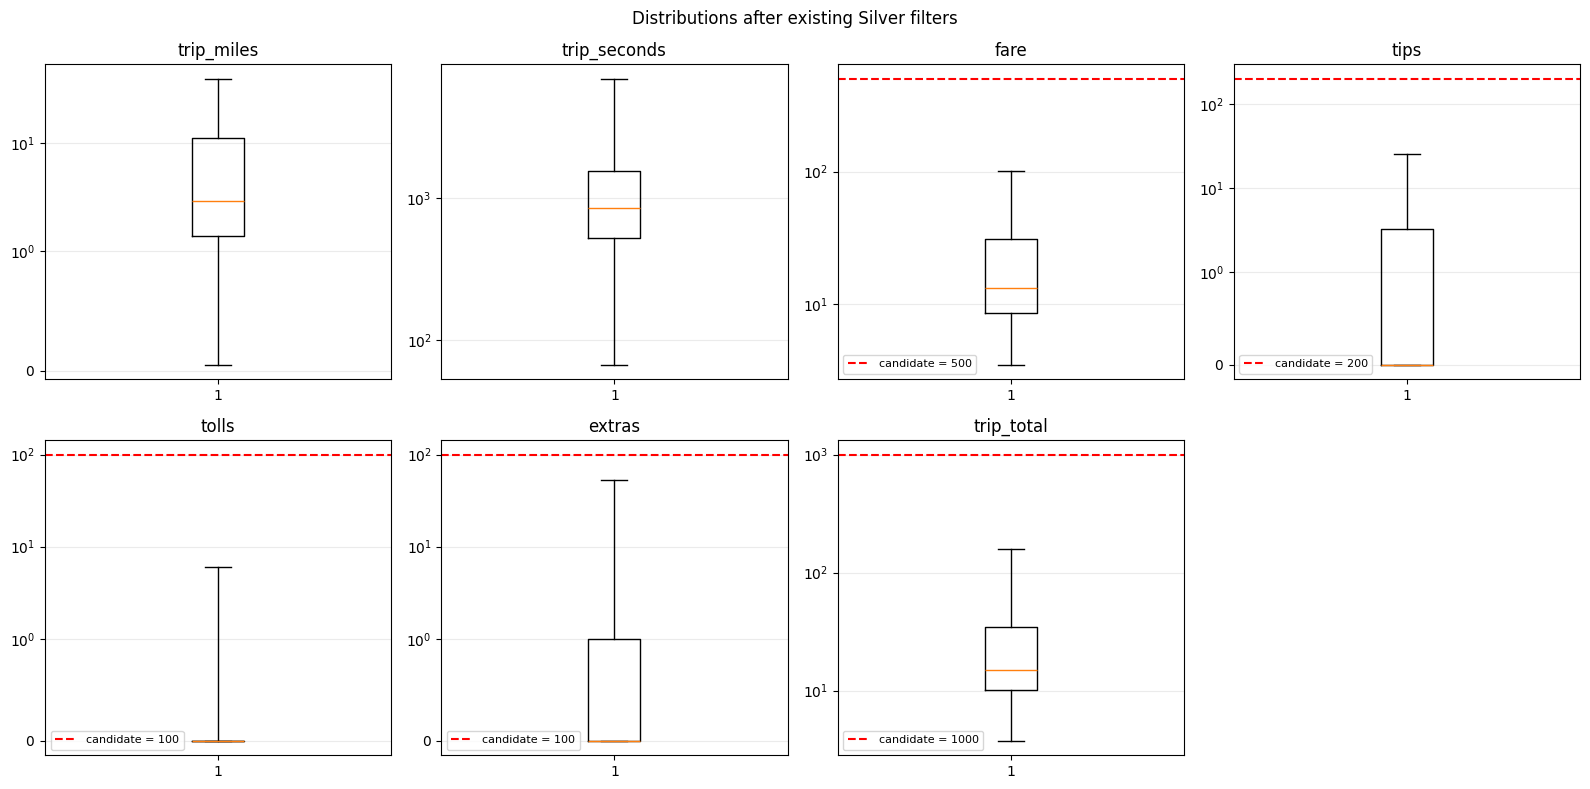

In [10]:
import matplotlib.pyplot as plt

# Exact tables use all rows; only the visualization uses a deterministic sample.
plot_sample = con.sql(f"""
    SELECT trip_id, {', '.join(profile_columns)}
    FROM ({BASELINE_FILTERED_TAXI_SQL})
    USING SAMPLE reservoir(200000 ROWS) REPEATABLE(42)
""").df()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for ax, column in zip(axes, profile_columns):
    ax.boxplot(
        plot_sample[column].dropna(),
        showfliers=False,
        whis=(0.1, 99.9),
    )
    ax.set_title(column)
    ax.set_yscale("symlog", linthresh=1)
    ax.grid(axis="y", alpha=0.25)
    if column in candidate_upper_limits:
        ax.axhline(
            candidate_upper_limits[column],
            color="red",
            linestyle="--",
            label=f"candidate = {candidate_upper_limits[column]}",
        )
        ax.legend(fontsize=8)

axes[-1].axis("off")
fig.suptitle("Distributions after existing Silver filters")
fig.tight_layout()
plt.show()

### Vorgeschlagene Interpretation

- Bestehende Grenzen für `trip_miles` (`0 < x <= 250`) und `trip_seconds` (`59 < x <= 10800`) beibehalten.
- Als konservative zusätzliche Grenzen `fare <= 500`, `tips <= 200`, `tolls <= 100`, `extras <= 100` und `trip_total <= 1000` prüfen.
- Die Grenzen liegen bewusst deutlich oberhalb der 99,9%-Quantile und entfernen nur extreme Werte.
- Für den Datenverlust ist die kombinierte Auswirkung maßgeblich; Einzelzahlen dürfen wegen Überschneidungen nicht addiert werden.

Dieser Abschnitt dokumentiert ausschließlich Kandidaten und schreibt keine Silver-Daten.

In [11]:
duckdb.sql(f"""
SELECT COUNT(*)
FROM read_parquet('{TAXI_PATH}')
WHERE trip_miles <= 0
""").show()

duckdb.sql(f"""
SELECT COUNT(*)
FROM read_parquet('{TAXI_PATH}')
WHERE trip_miles <= 0 and pickup_census_tract is null and dropoff_census_tract is null
""").show()

duckdb.sql(f"""
SELECT *
FROM read_parquet('{TAXI_PATH}')
WHERE trip_miles <= 0
""").show()

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│        21203 │
└──────────────┘

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│        10109 │
└──────────────┘

┌────────────────────┬───────────────────┬────────────────────────────┬────────────────────────────┬──────────────────────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬──────────────────────┬─────────────────────┬──────────────┬────────────┬─────────────────────┬──────────────────────┬───────────────────────┬────────────────────────┬────────┬────────┬────────┬────────┬────────────┬──────────────┬───────────────────────────────────┬──────────────────────────┬───────────────────────────┬──────────────────────────────────────┬───────────────────────────┬────────────────────────────┬──────────────────────────────────────┐
│        :id         │     :version      │        :created_at 

In [12]:
# very long trips
duckdb.sql(f"""
SELECT COUNT(*)
FROM read_parquet('{TAXI_PATH}')
WHERE trip_seconds > 14400
""").show()

# very short trips
# very long trips
duckdb.sql(f"""
SELECT mean(trip_miles)
FROM read_parquet('{TAXI_PATH}')
WHERE trip_seconds < 60
""").show()

# very expensive trips
duckdb.sql(f"""
SELECT count(*)
FROM read_parquet('{TAXI_PATH}')
WHERE fare > 500
""").show()

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│          156 │
└──────────────┘

┌─────────────────────┐
│  mean(trip_miles)   │
│       double        │
├─────────────────────┤
│ 0.08328033683152078 │
└─────────────────────┘

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│          100 │
└──────────────┘



In [13]:
duckdb.sql(f"""
SELECT pickup_centroid_location, COUNT(*)
FROM read_parquet('{TAXI_PATH}')
GROUP BY pickup_centroid_location
ORDER BY count(*) desc
""").show()

┌──────────────────────────────────────┬──────────────┐
│       pickup_centroid_location       │ count_star() │
│               varchar                │    int64     │
├──────────────────────────────────────┼──────────────┤
│ POINT (-87.9030396611 41.9790708201) │        27702 │
│ POINT (-87.6333080367 41.899602111)  │        26180 │
│ POINT (-87.913624596 41.9802643146)  │        25745 │
│ POINT (-87.6209929134 41.8849871918) │        14232 │
│ POINT (-87.6327464887 41.8809944707) │        14032 │
│ POINT (-87.6251921424 41.8788655841) │        12132 │
│ POINT (-87.6635175498 41.874005383)  │        11754 │
│ POINT (-87.642648998 41.8792550844)  │        11179 │
│ POINT (-87.6559981815 41.9442266014) │        10036 │
│ POINT (-87.6262149064 41.8925077809) │         7681 │
│                  ·                   │            · │
│                  ·                   │            · │
│                  ·                   │            · │
│ POINT (-87.7133688039 41.9865581808) │        

## Uniqueness Check / Duplicates

In [14]:
duckdb.sql(f"""
SELECT
    COUNT(*) AS n_rows,
    COUNT(DISTINCT trip_id) AS distinct_trip_id,
    COUNT(*) - COUNT(DISTINCT trip_id) AS duplicate_trip_id,

    COUNT(DISTINCT (taxi_id, trip_start_timestamp)) AS distinct_taxi_time_key,
    COUNT(*) - COUNT(DISTINCT (taxi_id, trip_start_timestamp)) AS duplicate_taxi_time_key,
    
    COUNT(DISTINCT (taxi_id, trip_start_timestamp, pickup_centroid_location)) AS distinct_taxi_time_pickup_key,
    COUNT(*) - COUNT(DISTINCT (taxi_id, trip_start_timestamp, pickup_centroid_location)) AS distinct_taxi_time_pickup_key
FROM read_parquet('{TAXI_PATH}')
""").show(max_width=500)

┌────────┬──────────────────┬───────────────────┬────────────────────────┬─────────────────────────┬───────────────────────────────┬───────────────────────────────┐
│ n_rows │ distinct_trip_id │ duplicate_trip_id │ distinct_taxi_time_key │ duplicate_taxi_time_key │ distinct_taxi_time_pickup_key │ distinct_taxi_time_pickup_key │
│ int64  │      int64       │       int64       │         int64          │          int64          │             int64             │             int64             │
├────────┼──────────────────┼───────────────────┼────────────────────────┼─────────────────────────┼───────────────────────────────┼───────────────────────────────┤
│ 291498 │           291498 │                 0 │                 278805 │                   12693 │                        287756 │                          3742 │
└────────┴──────────────────┴───────────────────┴────────────────────────┴─────────────────────────┴───────────────────────────────┴───────────────────────────────┘



es gibt Duplikate mit taxi_id und trip_start_timestamp

Limitation ist natürlich, dass trip_start_timestamp auf 15 Minuten gerundet ist, d. h. es könnten theoretisch 2 kurze Trips in einem taxi_id, trip_start_timestamp möglich sein, daher schauen wir uns noch die pickup location an, diese muss sich unterscheiden, damit der Trip gültig ist

D. h. gültige trips müssen eindeutig sein im Sinne taxi_id, trip_start_timestamp und pickup_centroid_location!

## Coverage Check

In [15]:
# Monthly
duckdb.sql(f"""
WITH base AS (
    SELECT TRY_CAST(trip_start_timestamp AS TIMESTAMP) AS trip_start
    FROM read_parquet('{TAXI_PATH}')
)
SELECT
    DATE_TRUNC('month', trip_start) AS month,
    COUNT(*) AS n_rows
FROM base
GROUP BY month
HAVING COUNT(*) < 500000
ORDER BY month
""").show(max_rows=100)

# Daily
duckdb.sql(f"""
WITH base AS (
    SELECT CAST(TRY_CAST(trip_start_timestamp AS TIMESTAMP) AS DATE) AS trip_date
    FROM read_parquet('{TAXI_PATH}')
)
SELECT
    trip_date,
    COUNT(*) AS n_rows
FROM base
GROUP BY trip_date
HAVING COUNT(*) < 10000
ORDER BY trip_date
""").show(max_rows=400)

# Missing days
coverage_report = duckdb.sql(f"""
WITH base AS (
    SELECT
        CAST(TRY_CAST(trip_start_timestamp AS TIMESTAMP) AS DATE) AS trip_date
    FROM read_parquet('{TAXI_PATH}')
    WHERE TRY_CAST(trip_start_timestamp AS TIMESTAMP) IS NOT NULL
),

date_bounds AS (
    SELECT
        MIN(trip_date) AS min_date,
        MAX(trip_date) AS max_date
    FROM base
),

date_spine AS (
    SELECT
        d::DATE AS trip_date
    FROM date_bounds,
    generate_series(min_date, max_date, INTERVAL 1 DAY) AS t(d)
),

daily_counts AS (
    SELECT
        trip_date,
        COUNT(*) AS n_rows
    FROM base
    GROUP BY trip_date
),

coverage AS (
    SELECT
        ds.trip_date,
        COALESCE(dc.n_rows, 0) AS n_rows,
        CASE
            WHEN dc.n_rows IS NULL THEN TRUE
            ELSE FALSE
        END AS is_missing_day
    FROM date_spine ds
    LEFT JOIN daily_counts dc
        ON ds.trip_date = dc.trip_date
)

SELECT
    trip_date,
    n_rows,
    is_missing_day
FROM coverage
ORDER BY trip_date
""").df()

missing_days = coverage_report.query("is_missing_day == True")

print(missing_days.to_string(index=False))

┌─────────────────────┬────────┐
│        month        │ n_rows │
│      timestamp      │ int64  │
├─────────────────────┼────────┤
│ 2026-04-01 00:00:00 │ 291498 │
└─────────────────────┴────────┘

┌───────────┬────────┐
│ trip_date │ n_rows │
│   date    │ int64  │
└───────────┴────────┘
        0 rows      

Empty DataFrame
Columns: [trip_date, n_rows, is_missing_day]
Index: []


In [16]:
low_volume_days = duckdb.sql(f"""
WITH base AS (
    SELECT
        CAST(TRY_CAST(trip_start_timestamp AS TIMESTAMP) AS DATE) AS trip_date
    FROM read_parquet('{TAXI_PATH}')
    WHERE TRY_CAST(trip_start_timestamp AS TIMESTAMP) IS NOT NULL
),

daily_counts AS (
    SELECT
        trip_date,
        COUNT(*) AS n_rows
    FROM base
    GROUP BY trip_date
),

stats AS (
    SELECT
        median(n_rows) AS median_daily_rows
    FROM daily_counts
)

SELECT
    dc.trip_date,
    dc.n_rows,
    s.median_daily_rows,
    ROUND(100.0 * dc.n_rows / s.median_daily_rows, 2) AS pct_of_median
FROM daily_counts dc
CROSS JOIN stats s
WHERE dc.n_rows < 0.5 * s.median_daily_rows
ORDER BY dc.trip_date
""").df()

print(low_volume_days.to_string(index=False))

Empty DataFrame
Columns: [trip_date, n_rows, median_daily_rows, pct_of_median]
Index: []


In [17]:
duckdb.sql(f"""select min(trip_start_timestamp) from read_parquet('{TAXI_PATH}') """).show()
duckdb.sql(f"""select max(trip_start_timestamp) from read_parquet('{TAXI_PATH}') """).show()

┌───────────────────────────┐
│ min(trip_start_timestamp) │
│         timestamp         │
├───────────────────────────┤
│ 2026-04-13 00:00:00       │
└───────────────────────────┘

┌───────────────────────────┐
│ max(trip_start_timestamp) │
│         timestamp         │
├───────────────────────────┤
│ 2026-04-26 23:45:00       │
└───────────────────────────┘



## Weather Data

In [18]:
WEATHER_PATH = PATHS.bronze_weatherdata

duckdb.sql(f"""
SELECT COUNT(*) AS n_rows
FROM read_parquet('{WEATHER_PATH}')
""").show()

duckdb.sql(f"""
DESCRIBE SELECT *
FROM read_parquet('{WEATHER_PATH}')
""").show(max_rows=100)

┌────────┐
│ n_rows │
│ int64  │
├────────┤
│   1005 │
└────────┘

┌─────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │ column_type │  null   │   key   │ default │  extra  │
│   varchar   │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ station     │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ valid       │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ lon         │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ lat         │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ tmpf        │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ relh        │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ drct        │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ sknt        │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ p01i        │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ vsby        │ DOUBLE 

### Column Description
station: weather station (`MDW`, `ORD`, or `IGQ`)
valid: timestamp
lon: longitude (metadata)
lat: latitude (metadata)

tmpf: temperature in degrees Fahrenheit
relh: relative humitidy in %
sknt: wind speed in knots
drct: wind direction in degrees
p01i: one-hour precipitation in inches (`0.0001` denotes a trace)
vsby: visibility in miles
skyc1: cloud coverage level 1
wxcodes: present-weather codes; missing means no special phenomenon reported



In [19]:
duckdb.sql(f"""
    select skyc1, count(*) 
    from read_parquet('{WEATHER_PATH}')
    group by skyc1
    order by count(*) desc""")

┌─────────┬──────────────┐
│  skyc1  │ count_star() │
│ varchar │    int64     │
├─────────┼──────────────┤
│ FEW     │          282 │
│ SCT     │          227 │
│ CLR     │          207 │
│ BKN     │          155 │
│ OVC     │          130 │
│ VV      │            4 │
└─────────┴──────────────┘

CLR - Clear
FEW - few clouds
SCT - scattered
BKN - broken
OVC - overcast
VV - vertical visibility

In [20]:
duckdb.sql(f"""
    select p01i, count(*) 
    from read_parquet('{WEATHER_PATH}')
    group by p01i
    order by count(*) desc""")

┌────────┬──────────────┐
│  p01i  │ count_star() │
│ double │    int64     │
├────────┼──────────────┤
│    0.0 │          919 │
│ 0.0001 │           37 │
│   0.01 │           15 │
│   0.02 │            9 │
│   0.03 │            5 │
│   0.09 │            3 │
│   0.05 │            2 │
│   0.18 │            2 │
│   0.08 │            2 │
│   0.49 │            1 │
│   0.07 │            1 │
│   0.06 │            1 │
│   0.12 │            1 │
│   0.32 │            1 │
│   0.19 │            1 │
│   1.01 │            1 │
│   0.71 │            1 │
│   0.16 │            1 │
│   0.77 │            1 │
│   0.38 │            1 │
└────────┴──────────────┘
  20 rows     2 columns

## Null Values

In [21]:
con = duckdb.connect()

columns = con.sql(f"""
DESCRIBE SELECT *
FROM read_parquet('{WEATHER_PATH}')
""").df()["column_name"].tolist()

parts = []

for col in columns:
    null_condition = f"""
        "{col}" IS NULL
        OR LOWER(TRIM(CAST("{col}" AS VARCHAR))) = 'null'
    """

    parts.append(f"""
    SELECT
        '{col}' AS column_name,
        COUNT(*) AS n_rows,
        SUM(CASE WHEN {null_condition} THEN 1 ELSE 0 END) AS n_nulls,
        ROUND(
            100.0 * SUM(CASE WHEN {null_condition} THEN 1 ELSE 0 END) / COUNT(*),
            2
        ) AS null_pct
    FROM read_parquet('{WEATHER_PATH}')
    """)

query = "\nUNION ALL\n".join(parts) + "\nORDER BY null_pct DESC"

null_report = con.sql(query).df()
print(null_report.to_string(index=False))

column_name  n_rows  n_nulls  null_pct
    wxcodes    1005    880.0     87.56
       drct    1005      1.0      0.10
        lat    1005      0.0      0.00
       p01i    1005      0.0      0.00
    station    1005      0.0      0.00
      valid    1005      0.0      0.00
      skyc1    1005      0.0      0.00
        lon    1005      0.0      0.00
       relh    1005      0.0      0.00
       vsby    1005      0.0      0.00
       sknt    1005      0.0      0.00
       tmpf    1005      0.0      0.00


## Coverage Check

- Min and max timestamp
- are there multiple timestamp for each hour?
- is there a timestamp for each hour between min and max timestamp?

In [22]:

duckdb.sql(f"""SELECT MIN(valid) from read_parquet('{WEATHER_PATH}')""").show()
duckdb.sql(f"""SELECT MAX(valid) from read_parquet('{WEATHER_PATH}')""").show()

┌─────────────────────┐
│    min("valid")     │
│      timestamp      │
├─────────────────────┤
│ 2026-04-13 00:51:00 │
└─────────────────────┘

┌─────────────────────┐
│    max("valid")     │
│      timestamp      │
├─────────────────────┤
│ 2026-04-26 23:55:00 │
└─────────────────────┘



In [23]:
duckdb.sql(f"""
    SELECT date_trunc('hour', valid) AS hour_ts, count(*)
    FROM read_parquet('{WEATHER_PATH}')
    GROUP BY date_trunc('hour', valid)
    HAVING count(*) > 1
    ORDER BY count(*) desc
""").show()

┌─────────────────────┬──────────────┐
│       hour_ts       │ count_star() │
│      timestamp      │    int64     │
├─────────────────────┼──────────────┤
│ 2026-04-13 01:00:00 │            3 │
│ 2026-04-23 03:00:00 │            3 │
│ 2026-04-13 22:00:00 │            3 │
│ 2026-04-14 12:00:00 │            3 │
│ 2026-04-14 15:00:00 │            3 │
│ 2026-04-14 20:00:00 │            3 │
│ 2026-04-15 07:00:00 │            3 │
│ 2026-04-15 08:00:00 │            3 │
│ 2026-04-15 09:00:00 │            3 │
│ 2026-04-15 10:00:00 │            3 │
│          ·          │            · │
│          ·          │            · │
│          ·          │            · │
│ 2026-04-25 03:00:00 │            3 │
│ 2026-04-25 07:00:00 │            3 │
│ 2026-04-25 14:00:00 │            3 │
│ 2026-04-26 02:00:00 │            3 │
│ 2026-04-26 09:00:00 │            3 │
│ 2026-04-26 17:00:00 │            3 │
│ 2026-04-26 20:00:00 │            3 │
│ 2026-04-24 00:00:00 │            2 │
│ 2026-04-24 01:00:00 │  

In [24]:
duckdb.sql(f"""-- Pfad anpassen
WITH raw AS (
    SELECT
        CAST(valid AS TIMESTAMP) AS valid_ts
    FROM read_parquet('{WEATHER_PATH}')
),

bounds AS (
    SELECT
        date_trunc('hour', min(valid_ts)) AS start_hour,
        date_trunc('hour', max(valid_ts)) AS end_hour
    FROM raw
),

expected_hours AS (
    SELECT generate_series AS hour_ts
    FROM bounds,
    generate_series(start_hour, end_hour, INTERVAL '1 hour')
),

observed_hours AS (
    SELECT
        date_trunc('hour', valid_ts) AS hour_ts,
        count(*) AS observations_in_hour
    FROM raw
    GROUP BY 1
),

hourly_check AS (
    SELECT
        e.hour_ts,
        COALESCE(o.observations_in_hour, 0) AS observations_in_hour,
        CASE
            WHEN o.hour_ts IS NULL THEN false
            ELSE true
        END AS has_data
    FROM expected_hours e
    LEFT JOIN observed_hours o
        ON e.hour_ts = o.hour_ts
)

SELECT *
FROM hourly_check
WHERE has_data = false
ORDER BY hour_ts;""").show()

┌───────────┬──────────────────────┬──────────┐
│  hour_ts  │ observations_in_hour │ has_data │
│ timestamp │        int64         │ boolean  │
└───────────┴──────────────────────┴──────────┘
                    0 rows                   

